In [1]:
import pandas as pd
df = pd.read_csv(r"D:\Hallucination Calibration In LLM's\databases\llm_reliability_dataset_final.csv")

In [2]:
df.columns


Index(['id', 'question_id', 'question', 'answer', 'model_name', 'band',
       'generation_index', 'temperature', 'top_p', 'mean_entropy',
       'max_entropy', 'early_entropy', 'entropy_variance', 'mean_logprob',
       'min_logprob', 'logprob_variance', 'sequence_loglikelihood',
       'answer_length_tokens', 'answer_length_chars', 'generation_time',
       'created_at', 'Correct Answers', 'Incorrect Answers', 'cos_sim_correct',
       'cos_sim_incorrect', 'cos_margin', 'label_cosine', 'nli_correct',
       'nli_incorrect', 'nli_margin', 'label_nli', 'label_hybrid'],
      dtype='object')

In [3]:
df.groupby("label_nli")["mean_entropy"].mean()

label_nli
0.0    0.407168
1.0    0.355932
Name: mean_entropy, dtype: float64

In [4]:
df.groupby("label_nli")["mean_logprob"].mean()

label_nli
0.0   -0.400372
1.0   -0.354785
Name: mean_logprob, dtype: float64

In [5]:
df[[
"mean_entropy",
"entropy_variance",
"mean_logprob",
"logprob_variance"
]].corr()

,mean_entropy,entropy_variance,mean_logprob,logprob_variance
mean_entropy,1.000000,0.801115,-0.891566,0.689882
entropy_variance,0.801115,1.000000,-0.712461,0.708952
mean_logprob,-0.891566,-0.712461,1.000000,-0.874092
logprob_variance,0.689882,0.708952,-0.874092,1.000000


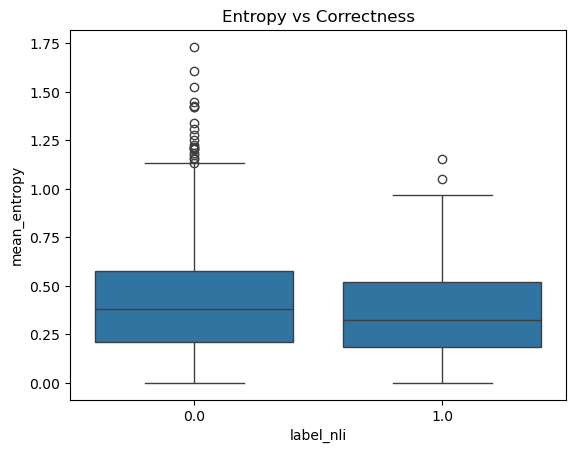

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="label_nli", y="mean_entropy", data=df)

plt.title("Entropy vs Correctness")
plt.show()

In [7]:
df.groupby("band")["label_nli"].mean()

band
1B    0.21500
3B    0.23125
7B    0.30375
Name: label_nli, dtype: float64

In [8]:
df.groupby("model_name")["label_nli"].mean()

model_name
TinyLlama/TinyLlama-1.1B-Chat-v1.0    0.1950
meta-llama/Llama-2-7b-chat-hf         0.1375
meta-llama/Llama-3.2-1B-Instruct      0.2350
meta-llama/Llama-3.2-3B-Instruct      0.1275
microsoft/Phi-3-mini-4k-instruct      0.3350
mistralai/Mistral-7B-Instruct-v0.2    0.4700
Name: label_nli, dtype: float64

In [9]:
df.groupby("label_nli")[[
"mean_entropy",
"entropy_variance",
"mean_logprob",
"logprob_variance"
]].mean()

,mean_entropy,entropy_variance,mean_logprob,logprob_variance
label_nli,,,,
0.0,0.407168,0.284304,-0.400372,0.481842
1.0,0.355932,0.251864,-0.354785,0.428318
